This notebook takes in a scatterer map in global artery coordinate system
and calculates the IVUS image for a single, rotating circular focused element.

First the global scatterer positions are transformed by the translation
vector and the rotation matrix that describes the transducer position
and orientation wrt the artery phantom coordinate system, where the transducer x axis is the rotation (catheter) axis.

Next the scatterer set is masked for a given slice thickness and based on visibility from the rotating element, such that a cylinder with axis on the x axis of the transducer and radius of the imaging depth.

Next the masked scatterer population in the local transducer coordinate system is rotated around the element rotation axis and RF data is collected for each angle, resulting in the r-theta polar image.

The RF data simulation is done with Field II, and MATLAB is required to be installed in the system, which runs in the background via PyField

Some remarks
- no attenuation is included at the moment. the blood/tissue values needs to be added to field ii setup
- NURD (non-uniform rotational distortion) can be added by adding a jitter to theta values
- The device bandwidth and curvature can be adjusted based on commercial device images

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import pyvista as pv
from scipy.interpolate import interp1d
import scipy.signal
from pyfield import PyField
from scipy.spatial.transform import Rotation
from tqdm import tqdm
import util
from matplotlib.patches import Circle

In [3]:
field = PyField()
field.field_init()

In [4]:
fs = 200e6 # field ii sampling rate. this should be high enough to converge the solution
c0 = 1540 # sound speed in the medium m/s
rho0 = 1000 # density kg/m^3

field.set_field('c',c0)
field.set_field('fs',fs)
field.set_field('att',0) # this needs to be updated to blood/tissue. see field ii manual for the definition

In [5]:
fc = 40e6 # transducer center frequency
fbw = 0.4 # transducer fractional bandwidth

In [6]:
t_acc, h_acc = util.define_impulse_resp(fc, fbw, fs)

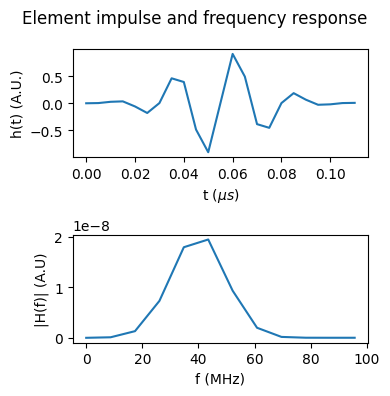

In [7]:
dt = t_acc[1]-t_acc[0]
f = np.fft.rfftfreq(len(t_acc),t_acc[1]-t_acc[0])
h_acc_f = np.fft.rfft(h_acc) * dt

fig, ax = plt.subplots(2,1, figsize=(4,4))
ax[0].plot(t_acc*1e6,h_acc)
ax[0].set_xlabel('t ($\mu s$)')
ax[0].set_ylabel('h(t) (A.U.)')

ax[1].plot(f/1e6,np.abs(h_acc_f))
ax[1].set_xlabel('f (MHz)')
ax[1].set_ylabel('|H(f)| (A.U)')

fig.suptitle('Element impulse and frequency response')

plt.tight_layout()
plt.show()


In [8]:
# excitation signal.
# Dirac delta is used so image is limited by device freq. resp.
excitation = t_acc-t_acc
excitation[0] = 1

In [9]:
elm_radius = 600e-6 # element radius (m)
elm_focal_radius = 4e-3 # element curvature (m)
ele_size = 200e-6 # mathematical element size (m). This should be small enough for convergence

In [10]:
# define transducer object
Th = field.xdc_concave(elm_radius, elm_focal_radius, ele_size)
field.xdc_impulse(Th, h_acc)
field.xdc_excitation(Th, excitation)

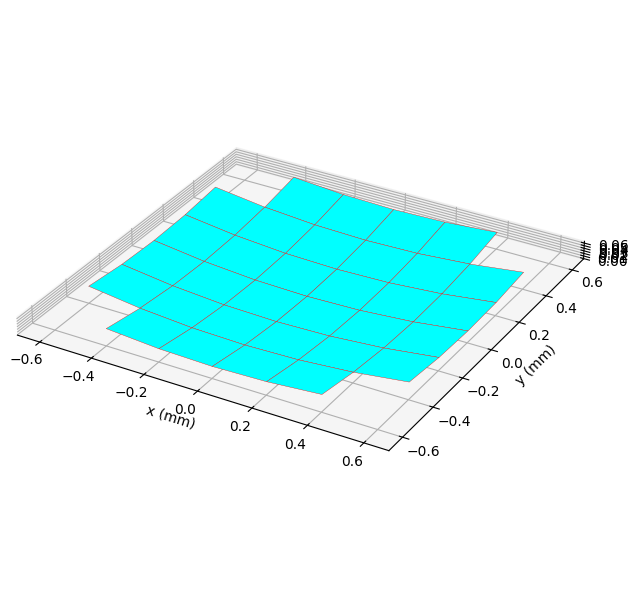

In [11]:
# show transducer
util.show_xducer(field, Th)

In [13]:
# load global scatterer map
npz_path = 'C:\\Users\\liams\\Documents\\GitHub\\endovascular\\sim\\usim\\data\\vascular_scattererMap.npz'
scatterers_global = np.load(npz_path)['scatterers_global']

In [14]:
# probe position and orientation
# probe coordinate system is defined where its x axis is the catheter axis
# which is also the element rotation axis, and z axis is the transducer normal
# The rotation and translation is defined with respect to the artery model coordinate system

euler_angles_deg = [0,-90,0]
rot = Rotation.from_euler('XYZ', euler_angles_deg, degrees=True)
rotation_mat = rot.as_matrix()

translation_vec = np.array([0,0,1e-2])

In [27]:
dead_r = 0.5e-3 # the initial dead zone where image is reconstructed beyond this depth
imaging_depth = 1e-3 # should be smaller than the max scatterer depth

# Slice is thick as the element size to hand-wavy account for beam spread 
# This should use simulated beam instead width maybe
x_slice_thickness = elm_radius * 2 

In [28]:
scatterers_local = []

wire_xvals = np.linspace(-x_slice_thickness/2,x_slice_thickness/2,101)

Npts = 5
r_range = np.linspace(1e-3,5e-3,Npts)
for ind, r_val in enumerate(r_range):
    theta_val = ind * 2*np.pi/len(r_range)
    for wire_xval in wire_xvals:
        scatterers_local.append([wire_xval,r_val*np.sin(theta_val),r_val*np.cos(theta_val),1])


scatterers_local = np.array(scatterers_local)

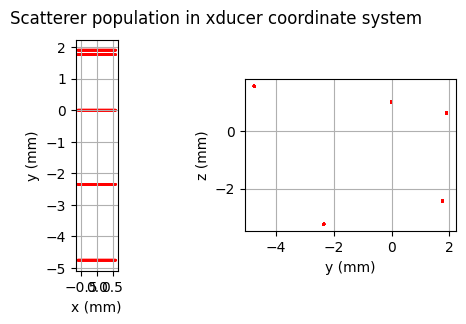

In [29]:
x = scatterers_local[:,0]
y = scatterers_local[:,1]
z = scatterers_local[:,2]
reflectivities = scatterers_local[:,3]

fig, ax = plt.subplots(1,2,figsize=(6, 3))
ax[0].scatter(x*1e3, y*1e3, c=reflectivities, cmap='rainbow_r', s=1)
ax[0].set_aspect('equal')
ax[0].set_xlabel('x (mm)')
ax[0].set_ylabel('y (mm)')
ax[0].grid()

ax[1].scatter(y*1e3, z*1e3, c=reflectivities, cmap='rainbow_r', s=1)
ax[1].set_aspect('equal')
ax[1].set_xlabel('y (mm)')
ax[1].set_ylabel('z (mm)')
ax[1].grid()

fig.suptitle('Scatterer population in xducer coordinate system')

plt.show()

In [30]:
t_max = 2 * imaging_depth / c0 + (2*np.max(t_acc))
dt = 1/fs
t_int = np.arange(0, t_max+dt, dt) # this is the time vector that's used to interpolate all RF data to same time base

In [31]:
dtheta_range_deg = 1
theta_range_deg = np.arange(0,360+dtheta_range_deg,dtheta_range_deg) # RF line collection rotation angles
theta_range = np.deg2rad(theta_range_deg)

r_range = t_int/2 * c0 # the imaging depth and the time of flight is related by the speed of sound in the medium

In [32]:
# rotate the scatterers and get RF data as a function of rotation angle theta

ts = []
RFdatas = []

for theta_deg in tqdm(theta_range_deg):
    angles = [theta_deg, 0, 0]

    rot = Rotation.from_euler('xyz', angles, degrees=True)
    rotated_xyz = rot.apply(scatterers_local[:, :3])
    scatterers = np.column_stack((rotated_xyz, scatterers_local[:, 3]))

    scatterers_frame = [s for s in scatterers if (np.linalg.norm(s[[0,1]])<=elm_radius) & (s[2]>dead_r)]
    scatterers_frame = np.array(scatterers_frame)

    if len(scatterers_frame)>0:
    
        [RFdata, t0] = field.calc_scat(Th, Th, scatterers_frame[:,:3], scatterers_frame[:,3])
        t = np.arange(len(RFdata)) / fs + t0
        
        intfun = interp1d(t, RFdata, axis=0, bounds_error=False, fill_value=0)
        RFdata_int = intfun(t_int)

    else:
        RFdata_int = np.zeros_like(t_int)
    
    ts.append(t_int)
    RFdatas.append(RFdata_int)

RFdatas = np.array(RFdatas)
ts = np.array(ts)

100%|██████████| 361/361 [00:02<00:00, 156.04it/s]


In [33]:
# envelope detection
RFdatas_h = scipy.signal.hilbert(RFdatas,axis=1)

# dB scale and normalize
im = np.abs(RFdatas_h)
im[im==0] = 1e-30
im_dB = 20 * np.log10(im)
im_dB_norm = im_dB - np.max(im_dB)

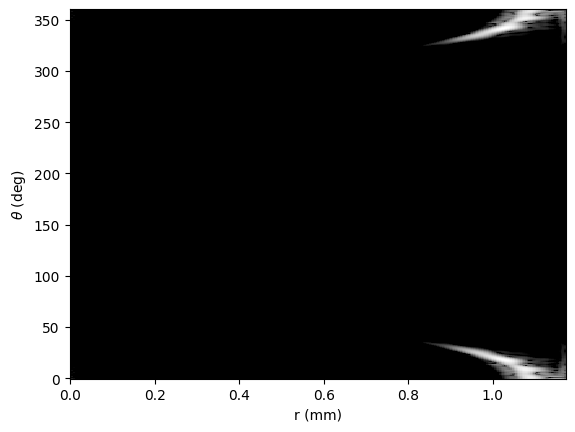

In [34]:
display_dBrange = 40

fig, ax = plt.subplots()
ax.pcolormesh(r_range*1e3, theta_range_deg, im_dB_norm, cmap='gray', vmin=-display_dBrange, vmax= 0)
ax.set_xlabel('r (mm)')
ax.set_ylabel(r'$\theta$ (deg)')
plt.show()

In [35]:
dtheta_range = theta_range[1] - theta_range[0]

In [36]:
cart_img, cart_x, cart_y = util.polar_to_cartesian(im_dB_norm[:,r_range<=imaging_depth], np.min(r_range), imaging_depth, dtheta_range)

In [37]:
r_cath = 3.5e-3/3/2 # 3.5 F for Eagle Eye. Not sure if correct

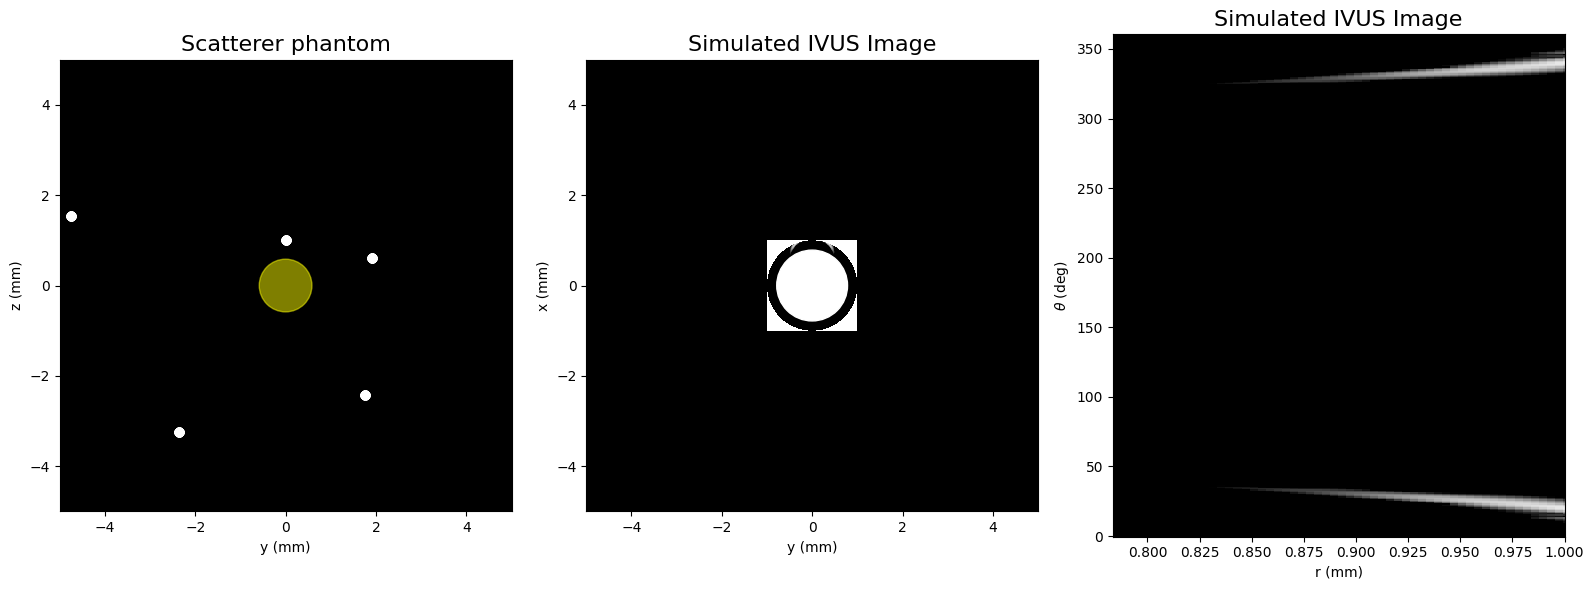

In [38]:
fig, ax = plt.subplots(1,3,figsize=(16, 6))

ax[0].plot(y*1e3, z*1e3, 'wo')
ax[0].set_aspect('equal')
ax[0].set_xlabel('y (mm)')
ax[0].set_ylabel('z (mm)')
ax[0].set_aspect(1)
# ax[0].grid()
ax[0].set_xlim(-5,5)
ax[0].set_ylim(-5,5)
ax[0].set_facecolor('k')
ax[0].set_title('Scatterer phantom', fontsize=16)

circle = Circle((0, 0), r_cath*1e3, color='yellow', alpha=0.5)
ax[0].add_patch(circle)



ax[1].pcolormesh(cart_y*1e3, cart_x*1e3, cart_img.T, cmap='gray', vmin=-40, vmax=0)
ax[1].set_aspect('equal')
ax[1].set_xlabel('y (mm)')
ax[1].set_ylabel('x (mm)')
ax[1].set_title('Simulated IVUS Image', fontsize=16)
ax[1].set_xlim(-5,5)
ax[1].set_ylim(-5,5)
# ax[1].grid()
ax[1].set_facecolor('k')

circle = Circle((0, 0), (r_cath+200e-6)*1e3, color='white', alpha=1)
ax[1].add_patch(circle)



ax[2].grid(0)
surf = ax[2].pcolormesh((r_range)*1e3, np.rad2deg(theta_range), im_dB_norm,cmap='gray',vmin=-40,vmax=0)
# ax[2].set_aspect(0.05)
ax[2].set_ylabel(r'$\theta$ (deg)')
ax[2].set_xlabel('r (mm)')
ax[2].set_title('Simulated IVUS Image', fontsize=16)
ax[2].set_xlim((r_cath+200e-6)*1e3, imaging_depth*1e3)
plt.tight_layout()

plt.show()